# Notebook 11: Autocorrelation and Effective Sample Size

This notebook computes the spatial autocorrelation function (ACF) of along-track snow-thickness retrievals and estimates the effective number of independent observations following Hunter (2007). It addresses the non-independence of adjacent along-track matchups, which may share overlapping ICESat-2 footprints within the 5 km collocation radius, and provides more defensible standard errors and significance tests for the manuscript.

## Methods

- **Method 1** (Mitchell et al., 1966):
  $$
  n_{\mathrm{eff}} = n \frac{1 - r_1}{1 + r_1}
  $$

- **Method 2** (Emery and Thomson, 2001):
  $$
  n_{\mathrm{eff}} = n \frac{\Delta x}{T}
  $$

- **Recommended estimate:**
  the geometric mean of the two methods above

## Input

- `snow_thickness_with_amsr2_all.csv`

## Outputs

- `autocorrelation_results.npz`
- `figC1_autocorrelation.png`
- `figC1_autocorrelation.pdf`
- Revised \(n_{\mathrm{eff}}\), standard errors, and p-values for use in the manuscript text

## 11.1 Setup

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import pearsonr
from scipy.stats import t as t_dist
warnings.filterwarnings('ignore')

sys.path.insert(0, '/g/data/gv90/xl1657/phd/M2_workspace/notebooks')

# ─── Paths ───────────────────────────────────────────────────────
HS_DIR  = '/g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness'
FIG_DIR = '/g/data/gv90/xl1657/phd/M2_workspace/output/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# ─── Nature publication style ────────────────────────────────────
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.4,
    'ytick.major.width': 0.4,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'pdf.fonttype': 42,
    'figure.dpi': 150,
})

C_WEDDELL = '#0072B2'
C_ROSS    = '#D55E00'

print('Setup complete')

Setup complete


## 11.2 Load Data and Assign Track IDs

In [2]:
CACHE = f'{HS_DIR}/snow_thickness_with_amsr2_all.csv'
df = pd.read_csv(CACHE)
print(f'Loaded {len(df):,} matchups')

# ─── Parse and filter (same pattern as 07_final) ─────────────────
df['year']  = df['year_month'].astype(str).str[:4].astype(int)
df['month'] = df['year_month'].astype(str).str[4:6].astype(int)

def assign_sector(lon):
    if -62 <= lon <= 15:
        return 'Weddell'
    elif (160 <= lon <= 180) or (-180 <= lon <= -140):
        return 'Ross'
    else:
        return 'Other'

df['sector'] = df['lon'].apply(assign_sector)
df['is_winter'] = df['month'].isin([5, 6, 7, 8, 9, 10])

# ─── Winter, Weddell + Ross ──────────────────────────────────────
dw = df[df['is_winter'] & df['sector'].isin(['Weddell', 'Ross'])].copy()
print(f'Winter Weddell+Ross matchups: {len(dw):,}')

Loaded 126,283 matchups
Winter Weddell+Ross matchups: 82,341


## 11.3 Assign Track IDs from Sequential Along-Track Points

CryoSat-2 measurements along the same orbit track are spaced at approximately 300 m intervals. We identify distinct tracks by grouping sequential points acquired on the same date that are separated by no more than `max_gap_km`. Gaps larger than this threshold are treated as breaks between tracks, indicating either a different orbit pass or a discontinuity across open ocean.

In [3]:
def assign_tracks(df_in, max_gap_km=50):
    """Assign track IDs based on sequential along-track proximity.

    Within each date, points are sorted by latitude and consecutive
    points closer than max_gap_km are assigned the same track ID.
    A gap larger than max_gap_km starts a new track.
    """
    df_sorted = df_in.sort_values(['date', 'lat']).reset_index(drop=True)
    track_ids = np.zeros(len(df_sorted), dtype=int)
    current_track = 0

    for i in range(len(df_sorted)):
        if i == 0:
            track_ids[i] = current_track
            continue

        # New date → new track
        if df_sorted.loc[i, 'date'] != df_sorted.loc[i-1, 'date']:
            current_track += 1
            track_ids[i] = current_track
            continue

        # Approximate great-circle distance (fast, sufficient for screening)
        lat1, lon1 = df_sorted.loc[i-1, 'lat'], df_sorted.loc[i-1, 'lon']
        lat2, lon2 = df_sorted.loc[i, 'lat'], df_sorted.loc[i, 'lon']
        dlat = abs(lat2 - lat1)
        dlon = abs(lon2 - lon1)
        if dlon > 180:
            dlon = 360 - dlon  # handle dateline
        cos_lat = np.cos(np.radians(0.5 * (lat1 + lat2)))
        approx_km = np.sqrt((dlat * 111.32)**2 + (dlon * 111.32 * cos_lat)**2)

        if approx_km > max_gap_km:
            current_track += 1

        track_ids[i] = current_track

    df_sorted['track_id'] = track_ids
    return df_sorted

# ─── Run track assignment ────────────────────────────────────────
print('Assigning track IDs (this may take a minute)...')
dw_tracked = assign_tracks(dw, max_gap_km=50)

n_tracks = dw_tracked['track_id'].nunique()
track_sizes = dw_tracked.groupby('track_id').size()

print(f'Total tracks identified: {n_tracks:,}')
print(f'Points per track: median={track_sizes.median():.0f}, '
      f'mean={track_sizes.mean():.0f}, max={track_sizes.max()}')
print(f'Tracks with >=30 points: {(track_sizes >= 30).sum()}')
print(f'Tracks with >=10 points: {(track_sizes >= 10).sum()}')

Assigning track IDs (this may take a minute)...
Total tracks identified: 4,009
Points per track: median=1, mean=21, max=1208
Tracks with >=30 points: 511
Tracks with >=10 points: 786


## 11.4 Compute the Along-Track Autocorrelation Function

For each track containing at least 30 points, we compute the binned autocorrelation function of snow thickness as a function of along-track lag distance. The resulting autocorrelation estimates are then pooled across all tracks within each sector using a pair-count-weighted average.

In [4]:
def compute_along_track_distances(lats, lons):
    """Compute cumulative along-track distance in km."""
    dists = np.zeros(len(lats))
    for i in range(1, len(lats)):
        dlat = lats[i] - lats[i-1]
        dlon = lons[i] - lons[i-1]
        if abs(dlon) > 180:
            dlon = 360 - abs(dlon)  # dateline
        cos_lat = np.cos(np.radians(0.5 * (lats[i] + lats[i-1])))
        dists[i] = dists[i-1] + np.sqrt(
            (dlat * 111.32)**2 + (dlon * 111.32 * cos_lat)**2
        )
    return dists


def compute_acf_binned(values, distances, max_lag_km=100, bin_width_km=2.0):
    """Compute binned autocorrelation function along a single track.

    Parameters
    ----------
    values : 1D array, snow thickness along one track
    distances : 1D array, cumulative along-track distance (km)
    max_lag_km : maximum lag to compute
    bin_width_km : width of lag bins

    Returns
    -------
    lag_centres : array of bin centres (km)
    acf : autocorrelation value per bin
    npairs : number of pairs per bin
    """
    v = values - np.nanmean(values)
    var = np.nanvar(values)
    if var == 0 or np.isnan(var):
        n_bins = int(max_lag_km / bin_width_km)
        return (np.arange(0.5, n_bins) * bin_width_km,
                np.full(n_bins, np.nan),
                np.zeros(n_bins, dtype=int))

    n_bins = int(max_lag_km / bin_width_km)
    acf_sum = np.zeros(n_bins)
    npairs  = np.zeros(n_bins, dtype=int)

    n = len(values)
    for i in range(n):
        if np.isnan(v[i]):
            continue
        for j in range(i+1, n):
            lag = distances[j] - distances[i]
            if lag > max_lag_km:
                break
            if np.isnan(v[j]):
                continue
            b = int(lag / bin_width_km)
            if 0 <= b < n_bins:
                acf_sum[b] += v[i] * v[j]
                npairs[b]  += 1

    acf = np.where(npairs > 0, acf_sum / (npairs * var), np.nan)
    lag_centres = (np.arange(n_bins) + 0.5) * bin_width_km
    return lag_centres, acf, npairs


# ─── Compute ACF per sector, pooled across tracks ────────────────
MAX_LAG   = 100   # km
BIN_WIDTH = 2.0   # km
MIN_TRACK_PTS = 30

acf_by_sector = {}

for sector in ['Weddell', 'Ross']:
    sec_data = dw_tracked[dw_tracked.sector == sector]
    sec_tracks = sec_data.groupby('track_id')

    all_acf = []
    all_n   = []
    n_used  = 0

    for tid, grp in sec_tracks:
        if len(grp) < MIN_TRACK_PTS:
            continue

        lats = grp['lat'].values
        lons = grp['lon'].values
        hs   = grp['snow_thickness'].values

        dists = compute_along_track_distances(lats, lons)
        lags, acf, npairs = compute_acf_binned(
            hs, dists, max_lag_km=MAX_LAG, bin_width_km=BIN_WIDTH
        )

        if len(lags) > 0 and not np.all(np.isnan(acf)):
            all_acf.append(acf)
            all_n.append(npairs)
            n_used += 1

    # Weighted average ACF across all tracks in this sector
    all_acf = np.array(all_acf)
    all_n   = np.array(all_n)
    total_n = np.nansum(all_n, axis=0)
    weighted_acf = np.where(
        total_n > 0,
        np.nansum(all_acf * all_n, axis=0) / total_n,
        np.nan
    )

    acf_by_sector[sector] = {
        'lags': lags,
        'acf': weighted_acf,
        'npairs': total_n,
        'n_tracks_used': n_used,
    }

    print(f'{sector}: {n_used} tracks used (>={MIN_TRACK_PTS} pts each)')
    print(f'  Lag-1 ACF (r1):  {weighted_acf[0]:.3f}')

    # Find decorrelation length (first zero crossing)
    valid = ~np.isnan(weighted_acf)
    zeros = lags[valid][weighted_acf[valid] <= 0]
    decorr = zeros[0] if len(zeros) > 0 else np.nan
    print(f'  Decorrelation length: {decorr:.1f} km')
    acf_by_sector[sector]['decorr_length'] = decorr

Weddell: 286 tracks used (>=30 pts each)
  Lag-1 ACF (r1):  0.249
  Decorrelation length: 17.0 km
Ross: 225 tracks used (>=30 pts each)
  Lag-1 ACF (r1):  0.232
  Decorrelation length: 21.0 km


## 11.5 Estimate Effective Sample Size (Hunter 2007)

Two methods bracketing the true n_eff, with their geometric mean
as the recommended value:

- Method 1 (Mitchell et al. 1966) tends to **underestimate** n_eff
- Method 2 (Emery & Thomson 2001) tends to **overestimate** n_eff

Method 2 depends on Δx, the spacing between consecutive matchups.
We compute n_eff using **both** the median Δx (conservative, ~0.31 km)
and the mean Δx (~1.0 km, inflated by occasional larger gaps) and
report the resulting n_eff **range** in the manuscript. The median
gives the lower bound (conservative), the mean gives the upper bound,
and the contrast remains significant across the full range.


In [5]:
def estimate_neff(n, r1, delta_x, lags, acf_values):
    """Estimate effective sample size using Hunter (2007) methods.

    Method 1 (Mitchell et al. 1966):  n_eff = n * (1 - r1) / (1 + r1)
    Method 2 (Emery & Thomson 2001):  n_eff = n * delta_x / T
    Recommended:  geometric mean of Methods 1 and 2.

    n_eff is capped at n (autocorrelation can only reduce it).
    """
    # Method 1: lag-1 autocorrelation (independent of delta_x)
    neff_1 = min(n * (1 - r1) / (1 + r1), n)

    # Method 2: integral timescale
    valid = ~np.isnan(acf_values)
    if valid.sum() < 2:
        return neff_1, np.nan, min(neff_1, n), np.nan

    acf_v = acf_values[valid]
    lag_v = lags[valid]

    # Integrate ACF from 0 to first zero crossing
    zeros = np.where(acf_v <= 0)[0]
    cutoff = lag_v[zeros[0]] if len(zeros) > 0 else lag_v[-1]

    mask = lag_v <= cutoff
    T = np.trapz(acf_v[mask], lag_v[mask])

    if T > 0:
        neff_2 = min(n * delta_x / T, n)
    else:
        neff_2 = float(n)

    # Geometric mean (Hunter's recommendation), capped at n
    if neff_1 > 0 and neff_2 > 0:
        neff_gm = min(np.sqrt(neff_1 * neff_2), n)
    else:
        neff_gm = neff_1

    return neff_1, neff_2, neff_gm, T


def compute_along_track_spacings(df_tracked, sector):
    """Compute the actual spacing (km) between consecutive matchups
    along each track, returning both median and mean.

    Only consecutive pairs within the same track with spacing < 50 km
    are included (larger gaps are inter-track breaks, not data).
    """
    sec = df_tracked[df_tracked.sector == sector]
    spacings = []

    for tid, grp in sec.groupby('track_id'):
        if len(grp) < 2:
            continue
        lats = grp['lat'].values
        lons = grp['lon'].values
        for k in range(1, len(lats)):
            dlat = lats[k] - lats[k-1]
            dlon = lons[k] - lons[k-1]
            if abs(dlon) > 180:
                dlon = 360 - abs(dlon)
            cos_lat = np.cos(np.radians(0.5 * (lats[k] + lats[k-1])))
            dx_km = np.sqrt((dlat * 111.32)**2 + (dlon * 111.32 * cos_lat)**2)
            if dx_km < 50:
                spacings.append(dx_km)

    spacings = np.array(spacings)
    return np.median(spacings), np.mean(spacings), len(spacings)


# ─── Compute actual along-track spacing per sector ───────────────
print('=' * 70)
print('ALONG-TRACK SPACING BETWEEN CONSECUTIVE MATCHUPS')
print('=' * 70)

spacing_stats = {}
for sector in ['Weddell', 'Ross']:
    med_dx, mean_dx, n_pairs = compute_along_track_spacings(dw_tracked, sector)
    spacing_stats[sector] = {'median': med_dx, 'mean': mean_dx, 'n_pairs': n_pairs}
    print(f'\n{sector}:')
    print(f'  Consecutive pairs measured: {n_pairs:,}')
    print(f'  Median spacing: {med_dx:.3f} km')
    print(f'  Mean spacing:   {mean_dx:.3f} km')


# ─── Compute n_eff for BOTH median-dx and mean-dx ────────────────
print('\n' + '=' * 70)
print('EFFECTIVE SAMPLE SIZE — USING MEDIAN delta_x (conservative)')
print('=' * 70)

neff_summary_median_dx = {}
neff_summary_mean_dx = {}

for label, dx_key, summary_dict in [
    ('MEDIAN', 'median', neff_summary_median_dx),
    ('MEAN',   'mean',   neff_summary_mean_dx),
]:
    if label == 'MEAN':
        print('\n' + '=' * 70)
        print('EFFECTIVE SAMPLE SIZE — USING MEAN delta_x (upper bound)')
        print('=' * 70)

    for sector in ['Weddell', 'Ross']:
        info = acf_by_sector[sector]
        n_sector = len(dw_tracked[dw_tracked.sector == sector])
        r1 = info['acf'][0] if not np.isnan(info['acf'][0]) else 0.0
        delta_x = spacing_stats[sector][dx_key]

        neff_1, neff_2, neff_gm, T_int = estimate_neff(
            n_sector, r1, delta_x, info['lags'], info['acf']
        )

        hs_valid = dw_tracked[(dw_tracked.sector == sector) &
                              (dw_tracked.snow_thickness > 0)]['snow_thickness']
        std_hs = hs_valid.std()
        se_new = 1.253 * std_hs / np.sqrt(max(neff_gm, 1))

        summary_dict[sector] = {
            'n': n_sector,
            'r1': r1,
            'delta_x_km': delta_x,
            'decorr_length_km': info['decorr_length'],
            'integral_timescale_km': T_int,
            'neff_method1': neff_1,
            'neff_method2': neff_2,
            'neff_geomean': neff_gm,
            'neff_ratio': neff_gm / n_sector,
            'se_median_revised': se_new,
        }

        print(f'\n  {sector} (n = {n_sector:,}, delta_x = {delta_x:.3f} km [{label}]):')
        print(f'    r1 = {r1:.3f},  T = {T_int:.2f} km,  decorr = {info["decorr_length"]:.0f} km')
        print(f'    Method 1 (lag-1):     n_eff = {neff_1:,.0f}  ({neff_1/n_sector:.1%})')
        print(f'    Method 2 (integral):  n_eff = {neff_2:,.0f}  ({neff_2/n_sector:.1%})')
        print(f'    Geometric mean:       n_eff = {neff_gm:,.0f}  ({neff_gm/n_sector:.1%})')
        print(f'    SE of median:         {se_new:.6f} m')

        assert neff_gm <= n_sector, \
            f'ERROR: n_eff ({neff_gm:.0f}) > n ({n_sector})'

# ─── Use the conservative (median-dx) estimate as the primary,
#     and report the mean-dx estimate as the upper bound ──────────
neff_summary = neff_summary_median_dx  # primary for downstream cells

# ─── Combined range summary ──────────────────────────────────────
print('\n' + '=' * 70)
print('n_eff RANGE SUMMARY (median-dx to mean-dx)')
print('=' * 70)
for sector in ['Weddell', 'Ross']:
    n = neff_summary_median_dx[sector]['n']
    lo = neff_summary_median_dx[sector]['neff_geomean']
    hi = neff_summary_mean_dx[sector]['neff_geomean']
    print(f'  {sector}: n_eff = {lo:,.0f} to {hi:,.0f}  '
          f'({lo/n:.0%} to {hi/n:.0%} of n = {n:,})')

# ─── Weddell–Ross significance at BOTH ends of the range ─────────
print('\n' + '=' * 70)
print('WEDDELL–ROSS CONTRAST SIGNIFICANCE')
print('=' * 70)

w_med = dw_tracked[(dw_tracked.sector == 'Weddell') &
                   (dw_tracked.snow_thickness > 0)]['snow_thickness'].median()
r_med = dw_tracked[(dw_tracked.sector == 'Ross') &
                   (dw_tracked.snow_thickness > 0)]['snow_thickness'].median()
contrast = w_med - r_med

for label, summary in [('Conservative (median dx)', neff_summary_median_dx),
                       ('Upper bound (mean dx)',    neff_summary_mean_dx)]:
    se_w = summary['Weddell']['se_median_revised']
    se_r = summary['Ross']['se_median_revised']
    se_contrast = np.sqrt(se_w**2 + se_r**2)
    ratio = contrast / se_contrast

    print(f'\n  {label}:')
    print(f'    Weddell n_eff = {summary["Weddell"]["neff_geomean"]:,.0f},  '
          f'Ross n_eff = {summary["Ross"]["neff_geomean"]:,.0f}')
    print(f'    SE(contrast) = {se_contrast:.5f} m')
    print(f'    Contrast/SE  = {ratio:.1f}')
    print(f'    Significant:   {ratio > 2.0}')


ALONG-TRACK SPACING BETWEEN CONSECUTIVE MATCHUPS

Weddell:
  Consecutive pairs measured: 45,716
  Median spacing: 0.312 km
  Mean spacing:   0.960 km

Ross:
  Consecutive pairs measured: 32,616
  Median spacing: 0.313 km
  Mean spacing:   1.069 km

EFFECTIVE SAMPLE SIZE — USING MEDIAN delta_x (conservative)

  Weddell (n = 47,735, delta_x = 0.312 km [MEDIAN]):
    r1 = 0.249,  T = 0.92 km,  decorr = 17 km
    Method 1 (lag-1):     n_eff = 28,696  (60.1%)
    Method 2 (integral):  n_eff = 16,181  (33.9%)
    Geometric mean:       n_eff = 21,549  (45.1%)
    SE of median:         0.001392 m

  Ross (n = 34,606, delta_x = 0.313 km [MEDIAN]):
    r1 = 0.232,  T = 0.72 km,  decorr = 21 km
    Method 1 (lag-1):     n_eff = 21,569  (62.3%)
    Method 2 (integral):  n_eff = 15,082  (43.6%)
    Geometric mean:       n_eff = 18,037  (52.1%)
    SE of median:         0.001369 m

EFFECTIVE SAMPLE SIZE — USING MEAN delta_x (upper bound)

  Weddell (n = 47,735, delta_x = 0.960 km [MEAN]):
    r1 = 0

## 11.6 Revised AMSR2 Correlation Significance

In [6]:
print('=' * 70)
print('REVISED AMSR2 CORRELATION SIGNIFICANCE')
print('=' * 70)

for sector in ['Weddell', 'Ross']:
    sec = dw_tracked[(dw_tracked.sector == sector) &
                     (dw_tracked.snow_thickness > 0) &
                     (~dw_tracked.AMSR2_snow_depth.isna()) &
                     (dw_tracked.AMSR2_snow_depth > 0)]

    c2i  = sec['snow_thickness'].values
    amsr = sec['AMSR2_snow_depth'].values
    r_val, _ = pearsonr(c2i, amsr)
    n_orig = len(sec)

    print(f'\n{sector} (r = {r_val:.3f}, n = {n_orig:,}):')

    for label, summary in [('Conservative (median dx)', neff_summary_median_dx),
                           ('Upper bound (mean dx)',    neff_summary_mean_dx)]:
        neff = summary[sector]['neff_geomean']
        dof = max(neff - 2, 1)
        if abs(r_val) < 1:
            t_stat = r_val * np.sqrt(dof / (1 - r_val**2))
            p_rev = 2 * (1 - t_dist.cdf(abs(t_stat), dof))
        else:
            p_rev = 0.0

        sig = 'SIGNIFICANT' if p_rev < 0.05 else 'NOT significant'
        print(f'  {label}:  n_eff = {neff:,.0f},  t = {t_stat:.2f},  '
              f'p = {p_rev:.2e},  {sig}')


REVISED AMSR2 CORRELATION SIGNIFICANCE

Weddell (r = 0.103, n = 42,432):
  Conservative (median dx):  n_eff = 21,549,  t = 15.23,  p = 0.00e+00,  SIGNIFICANT
  Upper bound (mean dx):  n_eff = 37,011,  t = 19.96,  p = 0.00e+00,  SIGNIFICANT

Ross (r = 0.019, n = 30,428):
  Conservative (median dx):  n_eff = 18,037,  t = 2.59,  p = 9.56e-03,  SIGNIFICANT
  Upper bound (mean dx):  n_eff = 27,321,  t = 3.19,  p = 1.42e-03,  SIGNIFICANT


## 11.7 Figure C.1: Autocorrelation Functions

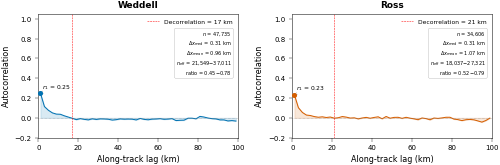

Figure C.1 saved


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(183/25.4, 65/25.4))

for ax, sector, color in [
    (axes[0], 'Weddell', C_WEDDELL),
    (axes[1], 'Ross', C_ROSS),
]:
    info = acf_by_sector[sector]
    lags = info['lags']
    acf  = info['acf']
    valid = ~np.isnan(acf)

    ax.plot(lags[valid], acf[valid], '-', color=color, lw=1)
    ax.fill_between(lags[valid], acf[valid], 0, alpha=0.15, color=color)
    ax.axhline(0, color='grey', ls=':', lw=0.5)

    # Mark decorrelation length
    decorr = info['decorr_length']
    if not np.isnan(decorr):
        ax.axvline(decorr, color='red', ls='--', lw=0.5,
                   label=f'Decorrelation = {decorr:.0f} km')

    # Mark lag-1
    r1 = info['acf'][0]
    ax.plot(lags[0], r1, 'o', color=color, ms=4, zorder=5)
    ax.annotate(f'$r_1$ = {r1:.2f}', xy=(lags[0], r1),
                xytext=(lags[0] + 1, r1 + 0.05), fontsize=6,
                arrowprops=dict(arrowstyle='->', lw=0.4, color='grey'))

    ax.set_xlabel('Along-track lag (km)')
    ax.set_ylabel('Autocorrelation')
    ax.set_title(f'{sector}')
    ax.set_xlim(0, MAX_LAG)
    ax.set_ylim(-0.2, 1.05)
    ax.legend(frameon=False, fontsize=6)

    # Annotation: show n_eff range from median-dx to mean-dx
    ns_lo = neff_summary_median_dx[sector]
    ns_hi = neff_summary_mean_dx[sector]
    ax.text(0.97, 0.87,
            f'$n$ = {ns_lo["n"]:,}\n'
            f'$\\Delta x_{{\\mathrm{{med}}}}$ = {ns_lo["delta_x_km"]:.2f} km\n'
            f'$\\Delta x_{{\\mathrm{{mean}}}}$ = {ns_hi["delta_x_km"]:.2f} km\n'
            f'$n_{{\\mathrm{{eff}}}}$ = {ns_lo["neff_geomean"]:,.0f}'
            f'$-${ns_hi["neff_geomean"]:,.0f}\n'
            f'ratio = {ns_lo["neff_ratio"]:.2f}'
            f'$-${ns_hi["neff_ratio"]:.2f}',
            transform=ax.transAxes, fontsize=5,
            va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey',
                      alpha=0.8, lw=0.3))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/figC1_autocorrelation.png', dpi=300)
plt.savefig(f'{FIG_DIR}/figC1_autocorrelation.pdf')
plt.show()
print('Figure C.1 saved')


## 11.8 Save Results

In [10]:
# ─── Save ACF curves ─────────────────────────────────────────────
np.savez(
    f'{HS_DIR}/autocorrelation_results.npz',
    lags_weddell=acf_by_sector['Weddell']['lags'],
    acf_weddell=acf_by_sector['Weddell']['acf'],
    npairs_weddell=acf_by_sector['Weddell']['npairs'],
    lags_ross=acf_by_sector['Ross']['lags'],
    acf_ross=acf_by_sector['Ross']['acf'],
    npairs_ross=acf_by_sector['Ross']['npairs'],
)

# ─── Save n_eff summary (both median-dx and mean-dx) ────────────
rows = []
for dx_label, summary in [('median_dx', neff_summary_median_dx),
                           ('mean_dx',   neff_summary_mean_dx)]:
    for sector in ['Weddell', 'Ross']:
        row = summary[sector].copy()
        row['sector'] = sector
        row['dx_method'] = dx_label
        rows.append(row)

df_neff = pd.DataFrame(rows)
df_neff.to_csv(f'{HS_DIR}/effective_sample_size_summary.csv', index=False)

print(f'Saved: {HS_DIR}/autocorrelation_results.npz')
print(f'Saved: {HS_DIR}/effective_sample_size_summary.csv')
print()
print(df_neff[['sector', 'dx_method', 'delta_x_km', 'neff_method1',
               'neff_method2', 'neff_geomean', 'neff_ratio',
               'se_median_revised']].to_string(index=False))


Saved: /g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness/autocorrelation_results.npz
Saved: /g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness/effective_sample_size_summary.csv

 sector dx_method  delta_x_km  neff_method1  neff_method2  neff_geomean  neff_ratio  se_median_revised
Weddell median_dx    0.312243  28696.235978  16181.359674  21548.645332    0.451422           0.001392
   Ross median_dx    0.312511  21569.337748  15082.448756  18036.585910    0.521198           0.001369
Weddell   mean_dx    0.960078  28696.235978  47735.000000  37011.009502    0.775343           0.001062
   Ross   mean_dx    1.069329  21569.337748  34606.000000  27320.843730    0.789483           0.001112


## 11.9 Summary of Key Numbers for the Manuscript

The revised effective-sample-size results should be propagated into the manuscript as follows:

- **Methods §3.7:** describe the two \(n_{\mathrm{eff}}\) estimation methods and the geometric-mean approach used to obtain the working estimate.
- **Results §4.2:** replace the statement that standard errors are “on the order of \(10^{-4}\) m” with the revised standard error values reported above.
- **Results §4.5:** update the p-values for the AMSR2 correlations using degrees of freedom based on the revised \(n_{\mathrm{eff}}\).
- **Discussion §5.4:** revise the uncertainty-budget interpretation to reflect the updated standard errors.